Step 1  : Data Gathering


In [1]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Khushi Kanade\OneDrive\Desktop\ML\classification-train-dataset.csv")
df.head(5)


,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0


In [2]:
df.shape

(136429, 14)

In [3]:
df.columns

Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136429 entries, 0 to 136428
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       136429 non-null  int64  
 1   Product ID               136429 non-null  object 
 2   Type                     136429 non-null  object 
 3   Air temperature [K]      136429 non-null  float64
 4   Process temperature [K]  136429 non-null  float64
 5   Rotational speed [rpm]   136429 non-null  int64  
 6   Torque [Nm]              136429 non-null  float64
 7   Tool wear [min]          136429 non-null  int64  
 8   Machine failure          136429 non-null  int64  
 9   TWF                      136429 non-null  int64  
 10  HDF                      136429 non-null  int64  
 11  PWF                      136429 non-null  int64  
 12  OSF                      136429 non-null  int64  
 13  RNF                      136429 non-null  int64  
dtypes: f

In [5]:
# check null values
df.isna().sum()

id                         0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [6]:
# check duplicates
df.duplicated().sum()

np.int64(0)

In [7]:
# handling for future cases
df = df.drop_duplicates()

In [8]:
df['Machine failure'].unique()

array([0, 1])

In [9]:
df['Machine failure'].value_counts()

Machine failure
0    134281
1      2148
Name: count, dtype: int64

In [10]:
(df['Machine failure'].value_counts()/len(df))*100

Machine failure
0    98.425555
1     1.574445
Name: count, dtype: float64

The data is very imbalanced, failure data points are very less , hence model will not learn failing scenarios properly. Hence, need to handle this imbalance in the data.

<Axes: ylabel='Machine failure'>

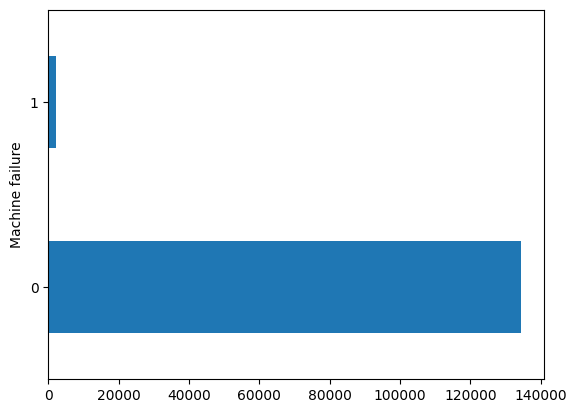

In [11]:
df['Machine failure'].value_counts().plot(kind='barh')

Step 3 : Seperate X and Y features

In [12]:
df.columns

Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [13]:

# removing insignificant columns in X
X = df.drop(columns=['id','Product ID','Machine failure'])
Y = df[['Machine failure']]

In [14]:
X.shape

(136429, 11)

In [15]:
Y.shape

(136429, 1)

In [16]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136429 entries, 0 to 136428
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Type                     136429 non-null  object 
 1   Air temperature [K]      136429 non-null  float64
 2   Process temperature [K]  136429 non-null  float64
 3   Rotational speed [rpm]   136429 non-null  int64  
 4   Torque [Nm]              136429 non-null  float64
 5   Tool wear [min]          136429 non-null  int64  
 6   TWF                      136429 non-null  int64  
 7   HDF                      136429 non-null  int64  
 8   PWF                      136429 non-null  int64  
 9   OSF                      136429 non-null  int64  
 10  RNF                      136429 non-null  int64  
dtypes: float64(3), int64(7), object(1)
memory usage: 11.4+ MB


Step 4 : Data cleaning and Pre-processing

In [17]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer


cat = list(X.select_dtypes(include='object').columns)
con = list(X.select_dtypes(include='number').columns)
num_pipe = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

cat_pipe = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore', sparse_output=False))

pre = ColumnTransformer([
    ('cat',cat_pipe,cat),
    ('con',num_pipe,con)
]).set_output(transform='pandas')

X_pre = pre.fit_transform(X)
X_pre.head()

,cat__Type_H,cat__Type_L,cat__Type_M,con__Air temperature [K],con__Process temperature [K],con__Rotational speed [rpm],con__Torque [Nm],con__Tool wear [min],con__TWF,con__HDF,con__PWF,con__OSF,con__RNF
0,0.0,1.0,0.0,0.395880,-0.246230,0.545416,-0.499711,0.556417,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
1,0.0,0.0,1.0,1.469856,1.558605,1.720308,-1.323028,1.494433,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
2,0.0,1.0,0.0,-0.302204,-1.040358,2.051873,-1.628831,-1.241447,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
3,0.0,1.0,0.0,0.610675,0.692284,0.026445,0.464745,1.447532,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
4,0.0,0.0,1.0,-1.000288,-0.679391,0.869773,-0.582043,-1.100744,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568


In [18]:
X_pre.shape

(136429, 13)

Step 6 : seperate training and testing data

In [19]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(X_pre,Y,train_size=0.66,stratify=Y,random_state=21)
print(xtrain.shape)
print(xtest.shape)
print(ytrain.shape)
print(ytest.shape)

(90043, 13)
(46386, 13)
(90043, 1)
(46386, 1)


Step 7 :  Model Building 

In [20]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
base_model = LogisticRegression()
base_model.fit(xtrain,ytrain)

c:\Users\Khushi Kanade\OneDrive\Desktop\ML\repository\venv\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [21]:
from sklearn.metrics import classification_report
ypreds_base = base_model.predict(xtest)
print(classification_report(ytest,ypreds_base))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45656
           1       0.99      0.77      0.87       730

    accuracy                           1.00     46386
   macro avg       0.99      0.89      0.93     46386
weighted avg       1.00      1.00      1.00     46386



In [22]:
cw_model = LogisticRegression(class_weight='balanced') # imbalanced data handling
cw_model.fit(xtrain,ytrain)

c:\Users\Khushi Kanade\OneDrive\Desktop\ML\repository\venv\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [23]:
from sklearn.metrics import classification_report
ypreds_cw = cw_model.predict(xtest)
print(classification_report(ytest,ypreds_cw))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     45656
           1       0.42      0.82      0.55       730

    accuracy                           0.98     46386
   macro avg       0.71      0.90      0.77     46386
weighted avg       0.99      0.98      0.98     46386



Sampling

In [24]:
pip install imblearn


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
from imblearn.over_sampling import SMOTE,ADASYN
smote = SMOTE()
x_sample1,y_sample1 = smote.fit_resample(xtrain,ytrain)

In [26]:
y_sample1.value_counts()

Machine failure
0                  88625
1                  88625
Name: count, dtype: int64

In [27]:
model3 = LogisticRegression()
model3.fit(x_sample1,y_sample1)

c:\Users\Khushi Kanade\OneDrive\Desktop\ML\repository\venv\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [28]:

ypreds_smote = model3.predict(xtest)
print(classification_report(ytest,ypreds_smote))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     45656
           1       0.38      0.82      0.52       730

    accuracy                           0.98     46386
   macro avg       0.69      0.90      0.75     46386
weighted avg       0.99      0.98      0.98     46386



ADASYN

In [29]:
ada = ADASYN()
x_sample2,y_sample2 = ada.fit_resample(xtrain,ytrain)

In [30]:
y_sample2.value_counts()

Machine failure
0                  88625
1                  88546
Name: count, dtype: int64

In [31]:
model4 = LogisticRegression()
model4.fit(x_sample2,y_sample2)

c:\Users\Khushi Kanade\OneDrive\Desktop\ML\repository\venv\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [32]:
ypreds_ada = model4.predict(xtest)
print(classification_report(ytest,ypreds_ada))

              precision    recall  f1-score   support

           0       1.00      0.72      0.84     45656
           1       0.05      0.92      0.10       730

    accuracy                           0.72     46386
   macro avg       0.52      0.82      0.47     46386
weighted avg       0.98      0.72      0.83     46386



ADASYN gives better recall for class '1'.

Decision Tree classifier

In [33]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_leaf=3,
    min_samples_split=5
)

model.fit(x_sample2,y_sample2)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,5
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [34]:
model.score(x_sample2,y_sample2)

0.7734279312077033

In [35]:
model.score(xtest,ytest)

0.8074419005734489

Hyperparameter Tuning

In [36]:
params ={
    'max_depth':[3,4,5,6,7],
    'min_samples_leaf':[1,2,3,4,5,9,11],
    'min_samples_split':[3,5,7,9,10],
    'criterion':['gini','entropy']
}

In [37]:
from sklearn.model_selection import RandomizedSearchCV
base_model = DecisionTreeClassifier()
rscv = RandomizedSearchCV(estimator=base_model,param_distributions=params,cv=3,scoring='f1_macro')
rscv.fit(x_sample2,y_sample2)

,estimator,DecisionTreeClassifier()
,param_distributions,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 4, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [3, 5, ...]}"
,n_iter,10
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


Model Evaluation

In [38]:
rscv.best_params_

{'min_samples_split': 10,
 'min_samples_leaf': 1,
 'max_depth': 7,
 'criterion': 'gini'}

In [39]:
rscv.best_score_

np.float64(0.7871777808061301)

In [40]:
best_dtc = rscv.best_estimator_
best_dtc

,criterion,'gini'
,splitter,'best'
,max_depth,7
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [41]:
best_dtc.score(x_sample2,y_sample2)

0.8094722048190731

In [42]:
best_dtc.score(xtest,ytest)

0.8374293968007589

Confusion Matrix and Classification Report

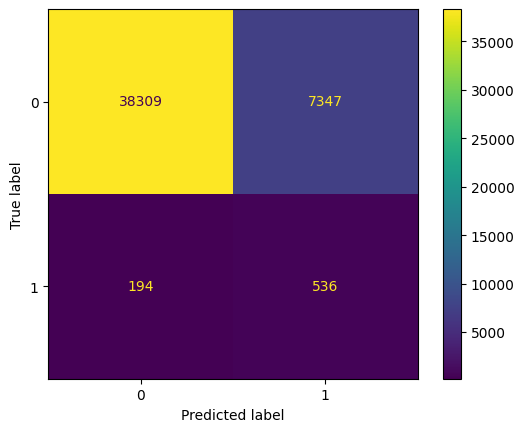

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(best_dtc,xtest,ytest)

In [44]:
from sklearn.metrics import classification_report
ypreds = model.predict(xtest)
print(classification_report(ytest,ypreds))

              precision    recall  f1-score   support

           0       1.00      0.81      0.89     45656
           1       0.06      0.81      0.12       730

    accuracy                           0.81     46386
   macro avg       0.53      0.81      0.50     46386
weighted avg       0.98      0.81      0.88     46386



In [45]:
from sklearn.metrics import f1_score
f1 = f1_score(ytest,ypreds,average='macro')
f1

0.5045759479188956

Plotting decision tree

In [46]:
x_sample2.columns

Index(['cat__Type_H', 'cat__Type_L', 'cat__Type_M', 'con__Air temperature [K]',
       'con__Process temperature [K]', 'con__Rotational speed [rpm]',
       'con__Torque [Nm]', 'con__Tool wear [min]', 'con__TWF', 'con__HDF',
       'con__PWF', 'con__OSF', 'con__RNF'],
      dtype='object')

RandomForest Classifier

In [47]:
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier

model_rnd = RandomForestClassifier(
    n_estimators=50,
    max_depth=10
)
model_rnd.fit(x_sample2,y_sample2)

c:\Users\Khushi Kanade\OneDrive\Desktop\ML\repository\venv\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,50
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [48]:
model_rnd.score(xtrain,ytrain)

0.9045456059882501

In [49]:
model_rnd.score(xtest,ytest)

0.8949683094036994

In [50]:
params = {
    'n_estimators':[40,50,100,150,200],
    'max_depth':[5,7,10,12,14,16,18,20]
}

In [51]:
from sklearn.model_selection import RandomizedSearchCV
base_model = RandomForestClassifier()
rscv = RandomizedSearchCV(estimator=base_model,param_distributions=params,cv=5,scoring='f1_macro')
rscv.fit(x_sample2,y_sample2)

c:\Users\Khushi Kanade\OneDrive\Desktop\ML\repository\venv\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Khushi Kanade\OneDrive\Desktop\ML\repository\venv\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Khushi Kanade\OneDrive\Desktop\ML\repository\venv\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Khushi Kanade\OneDrive\Desktop\ML\repository\venv\lib\site-packages\sklearn\base.py:1

,estimator,RandomForestClassifier()
,param_distributions,"{'max_depth': [5, 7, ...], 'n_estimators': [40, 50, ...]}"
,n_iter,10
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [52]:
rscv.best_score_

np.float64(0.9169688294147743)

In [53]:
rscv.best_params_

{'n_estimators': 100, 'max_depth': 20}

In [54]:
best_model_rnd = rscv.best_estimator_

In [55]:
import joblib
joblib.dump(pre,'pre.joblib')
joblib.dump(best_model_rnd,'model_random.joblib')

['model_random.joblib']

Evaluation of Random Forest model

In [56]:
ypred_rnd = best_model_rnd.predict(xtest)
ypred_rnd[:5]

array([0, 0, 0, 0, 0])

In [57]:
from sklearn.metrics import classification_report
print(classification_report(ytest,ypred_rnd))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99     45656
           1       0.36      0.68      0.47       730

    accuracy                           0.98     46386
   macro avg       0.68      0.83      0.73     46386
weighted avg       0.98      0.98      0.98     46386



Ensemble: Gradient Boosting

In [58]:
model2 = GradientBoostingClassifier(n_estimators=100,max_depth=10,learning_rate=0.01)
model2.fit(x_sample2,y_sample2)

c:\Users\Khushi Kanade\OneDrive\Desktop\ML\repository\venv\lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,loss,'log_loss'
,learning_rate,0.01
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,10
,min_impurity_decrease,0.0
,init,None


In [59]:
model2.score(xtrain,ytrain)

0.9200270981642105

In [60]:
model2.score(xtest,ytest)

0.9087655758202906

In [61]:
params = {
    'learning_rate':[0.1,0.01] 
}

In [62]:
base_model2 = GradientBoostingClassifier()
rscv2 = RandomizedSearchCV(estimator=base_model2,param_distributions=params,scoring='f1_macro')
rscv2.fit(x_sample2,y_sample2)

c:\Users\Khushi Kanade\OneDrive\Desktop\ML\repository\venv\lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 2 is smaller than n_iter=10. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\Khushi Kanade\OneDrive\Desktop\ML\repository\venv\lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Khushi Kanade\OneDrive\Desktop\ML\repository\venv\lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Khushi Kanade\OneDrive\Desktop\ML\repository\venv\lib\site-packages\sklearn\preprocessing\_label.py:110: DataConve

,estimator,GradientBoostingClassifier()
,param_distributions,"{'learning_rate': [0.1, 0.01]}"
,n_iter,10
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [63]:
rscv2.best_score_

np.float64(0.8309357188512813)

In [64]:
rscv2.best_params_

{'learning_rate': 0.1}

In [65]:
best_model_grad = rscv2.best_estimator_

Evaluation of Gradient Boost CLassifier

In [66]:
ypred_grad = best_model_grad.predict(xtest)

In [67]:
print(classification_report(ytest,ypred_grad))

              precision    recall  f1-score   support

           0       1.00      0.87      0.93     45656
           1       0.09      0.84      0.16       730

    accuracy                           0.87     46386
   macro avg       0.54      0.85      0.54     46386
weighted avg       0.98      0.87      0.91     46386



In [68]:
joblib.dump(best_model_grad,'model_grad.joblib')

['model_grad.joblib']

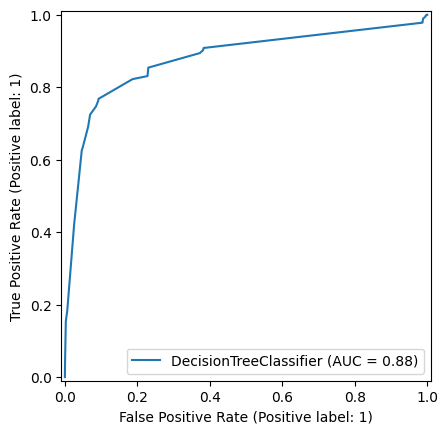

In [70]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(model,xtrain,ytrain)

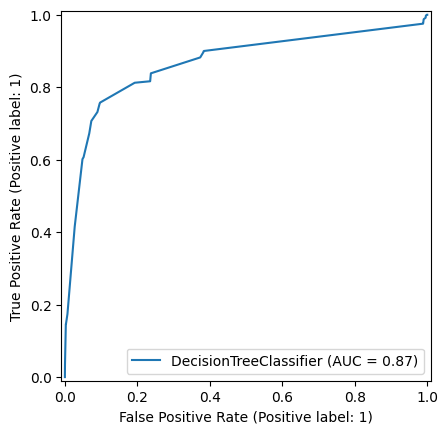

In [71]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(model,xtest,ytest)

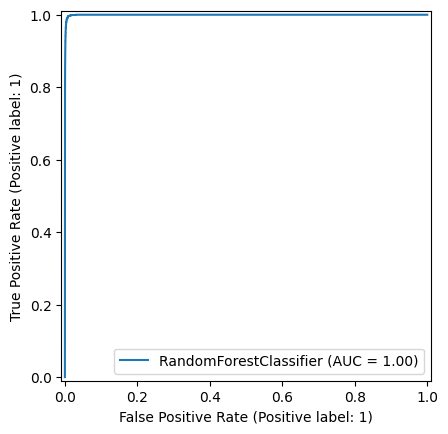

In [80]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(best_model_rnd,xtrain,ytrain)

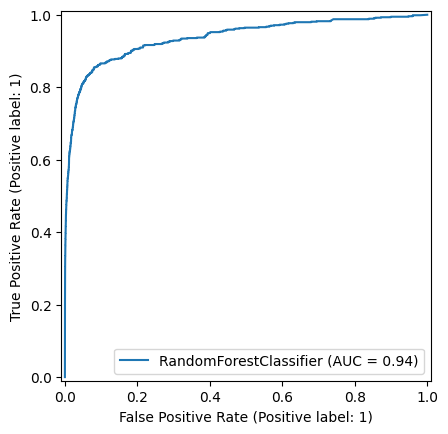

In [81]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(best_model_rnd,xtest,ytest)

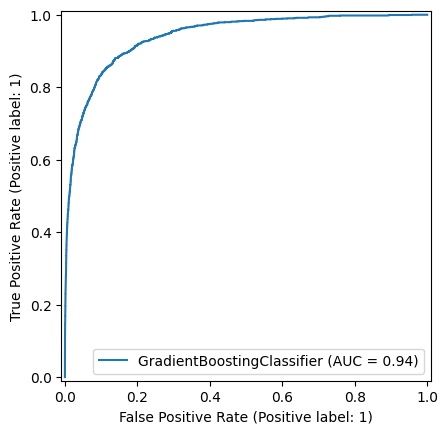

In [77]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(best_model_grad,xtrain,ytrain)

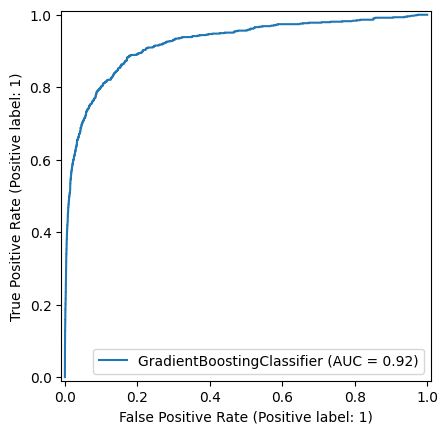

In [79]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(best_model_grad,xtest,ytest)

Hence we will choose the above model, as it has AUC>0.9 and also generalises better on training data.